Deinteralacing Eye camera 

In [24]:
import os
import cv2
import subprocess
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

#import raw EYE video data

vidfile = 'T:/freely_moving_ephys/nn_dataset/070921_J553RT/fm1/070921_J553RT_control_Rig2_fm1_REYE.avi'

#assign deinterlaced video filepath

savepath = 'T:/freely_moving_ephys/nn_dataset/070921_J553RT/fm1/070921_J553RT_control_Rig2_fm1_REYEdeinter.avi'

#function scrapped from the ephys pipeline

def deinterlace(vidfile, savepath, exp_fps=30, quiet=True):
    """ Deinterlace a video.

    Parameters
    ----------
    path : str
        Path to the video file.
    savepath : str
        Path to save the new video file. Default is None.
    rotate : bool
        Whether to rotate the video 180 degrees. Default is True.
    exp_fps : int
        Expected frame rate of the video. If the video matches
        this frame rate (in Hz), it will be deinterlaced. Otherwise,
        it will be skipped. Default is 30 Hz.
    quiet : bool
        Whether to suppress the output from ffmpeg. Default is True.
    
    Returns
    -------
    savepath : str
        Path to the new video file.

    """

    # Open video, get frame count and rate
    cap = cv2.VideoCapture(vidfile)
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Skip this video if it doesn't match the expected frame rate.
    if fps != exp_fps:
        return
        
    # Create the FFMPEG commands for video rotation.
    #vf_val = 'yadif=1:-1:0, vflip, hflip, scale=640:480'
    vf_val = 'yadif=1:-1:, scale=640:480'

    # Create the full FFMPEG command
    cmd = ['ffmpeg', '-i', vidfile, '-vf', vf_val, '-c:v', 'libx264',
          '-preset', 'slow', '-crf', '19', '-c:a', 'aac', '-b:a',
          '256k', '-y', savepath]
    
    # Set the log level
    if quiet is True:
        cmd.extend(['-loglevel', 'quiet'])

    # Run the FFMPEG command.
    subprocess.run(cmd, capture_output=True, text=True)

    return savepath

# process deinterlacing (it takes upto 10 minutes, depending on the computing power)

#deinterlace(vidfile, savepath, exp_fps=30, quiet=True)



In [7]:
os.path(str(\\goeppert\Vol2\mike\recordings\041825\F3LILT\oa_cam\041825_F3LILT_control_Rig2_oa_cam_REYE.avi))

SyntaxError: unexpected character after line continuation character (3465350911.py, line 1)

In [25]:
eye_vid = r"\\goeppert\Vol2\mike\recordings\041825\F3LILT\oa_cam\041825_F3LILT_control_Rig2_oa_cam_REYE.avi"
eye_save =  r"\\goeppert\Vol2\mike\recordings\041825\F3LILT\oa_cam\041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi"


In [20]:
eye_vid.replace(os.sep, "/")

'/goeppert/Vol2/mike\recordings!825/F3LILT/oa_cam!825_F3LILT_control_Rig2_oa_cam_REYE.avi'

In [2]:
world_vid = r"\\goeppert\Vol2\mike\recordings\041725\F3LILT\oa_cam\041725_F3LILT_control_Rig2_oa_cam_TOP1.avi"
world_save =  r"\\goeppert\Vol2\mike\recordings\041725\F3LILT\oa_cam\041725_F3LILT_control_Rig2_oa_cam_TOP1deinter.avi"

In [9]:
deinterlace(r'\\\\goeppert\\Vol2\\mike\\recordings\\041825\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYE.avi',r'\\\\goeppert\\Vol2\\mike\\recordings\\041825\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi')

In [22]:
deinterlace(eye_vid.replace(os.sep, '/'), eye_save.replace(os.sep, '/'), exp_fps=30, quiet=True)

'//goeppert/Vol2/mike/recordings/041825/F3LILT/oa_cam/041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi'

In [26]:
deinterlace(eye_vid, eye_save, exp_fps=30, quiet=True)

'\\\\goeppert\\Vol2\\mike\\recordings\\041825\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi'

In [15]:
deinterlace(r"\\goeppert\Vol2\\mike\recordings\041825\\F3LILT\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYE.avi",r"\\goeppert\Vol2\\mike\recordings\041825\\F3LILT\oa_cam\041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi"
            ,exp_fps=30, quiet=True)

'\\\\goeppert\\Vol2\\\\mike\\recordings\\041825\\\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi'

In [11]:
deinterlace(world_vid, world_save, exp_fps=30, quiet=True)

NameError: name 'world_vid' is not defined

In [30]:
file_path = '\\\\goeppert\\Vol2\\mike\\recordings\\041825\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYE.avi'
os.path.exists(file_path)

True

In [29]:
os.path.normpath(file_path)

'\\\\goeppert\\Vol2\\mike\\recordings\\041825\\F3LILT\\oa_cam\\041825_F3LILT_control_Rig2_oa_cam_REYE.avi'

In [3]:
dtypes = np.dtype([
            ("none0",np.uint16),
            ("none1",np.uint16),
            ("none2",np.uint16),
            ("frame_TTL",np.uint16),
            ("none4",np.uint16),
            ("none5",np.uint16),
            ("none6",np.uint16),
            ("stim_TTL",np.uint16)
        ])

In [4]:
binary_in = pd.DataFrame(np.fromfile(r"\\goeppert\Vol2\mike\040325_test_doi_Rig2_hf1_wn_IMU.bin", dtypes, -1, ''))
binary_in = binary_in[['frame_TTL','stim_TTL']]

data = 10 * (binary_in.astype(float)/(2**16) - 0.5)

In [6]:
binary_in

,frame_TTL,stim_TTL
0,9290,35791
1,9268,35744
2,9230,35652
3,9222,35631
4,9229,35647
...,...,...
843771,7817,35645
843772,7823,35645
843773,7831,35653
843774,7785,35607


In [7]:
data.frame_TTL

0        -3.582458
1        -3.585815
2        -3.591614
3        -3.592834
4        -3.591766
            ...   
843771   -3.807220
843772   -3.806305
843773   -3.805084
843774   -3.812103
843775   -3.805695
Name: frame_TTL, Length: 843776, dtype: float64

In [11]:
from matplotlib import pyplot as plt

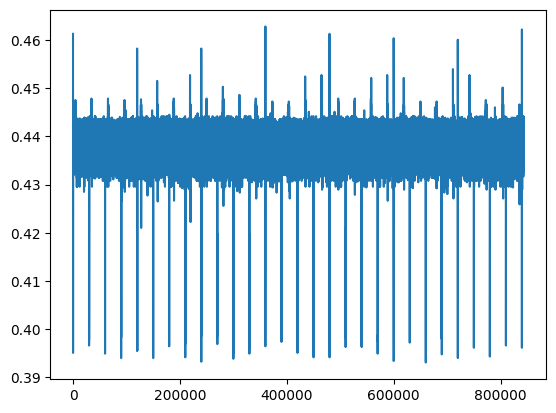

In [13]:
plt.plot(data.stim_TTL)

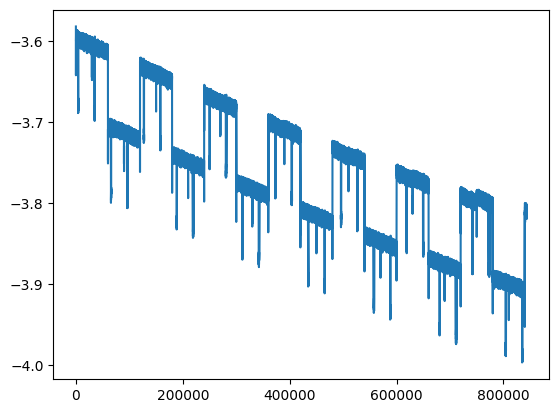

In [12]:
plt.plot(data.frame_TTL)